# House Price Prediction

## Objective

Predict house prices using Machine Learning

Algorithm: 
- Multiple Linear Regression withoutbusing scikit learn

Libraries:
- Numpy
- Pandas
- Matplotlib
- seaborn 

Developer: 
Sahil Bhayre

# 1. Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# 2. Load Dataset

In [2]:
data = pd.read_csv("Housing.csv")

# 3. Exploratory Data Analysis (EDA)

## 3.1 Display Dataset

In [3]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960.0,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500.0,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420.0,4,1,2,yes,yes,NaN,no,yes,2,no,unfurnished


In [4]:
data.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000.0,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400.0,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620.0,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910.0,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850.0,3,1,2,yes,no,no,no,no,0,no,unfurnished


## 3.2 Dataset Info

In [6]:
data.shape

(545, 13)

In [8]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              544 non-null    float64
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          544 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 55.5+ KB


## 3.3 Check Missing

In [10]:
data.isnull().sum()

price               0
area                1
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            1
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
data[data.isnull().any(axis=1)]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
4,11410000,7420.0,4,1,2,yes,yes,NaN,no,yes,2,no,unfurnished
24,8575000,NaN,3,2,2,yes,no,no,no,yes,2,no,furnished


## 3.4 Statistical Summary

In [12]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,544.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5143.832721,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2166.474646,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3596.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4580.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 3.5 Distribution Analysis

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

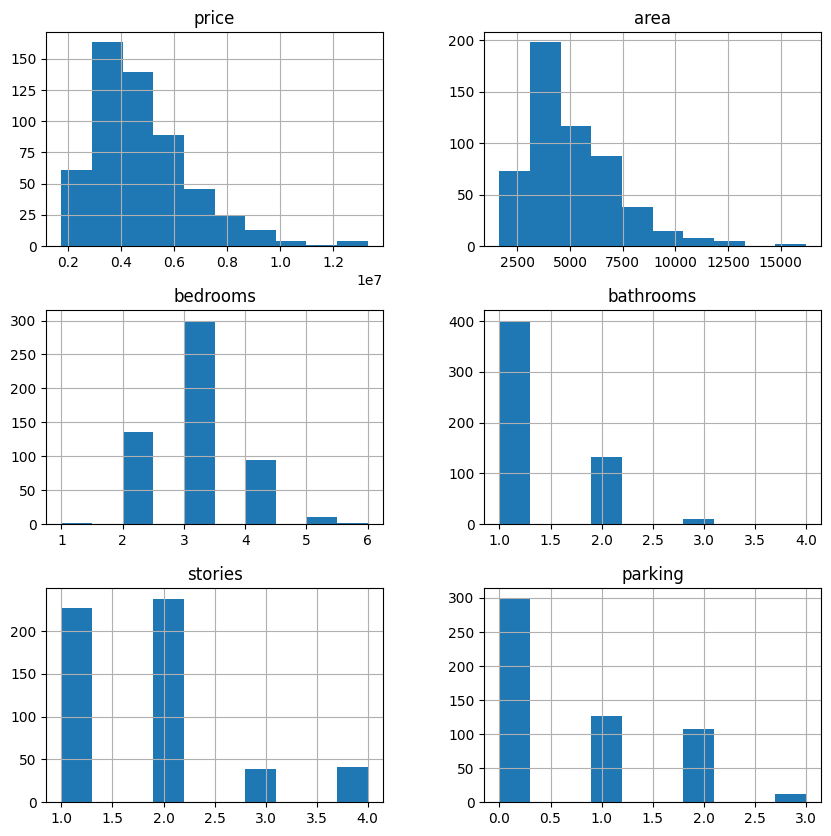

In [14]:
data.hist(figsize=(10, 10))

## 3.6 Correlation Analysis

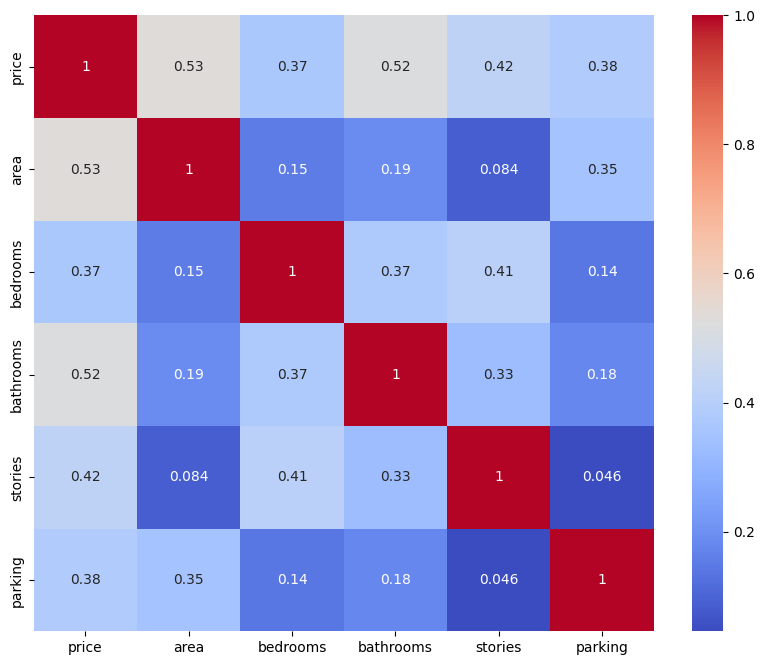

In [15]:
data.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

## 3.7 Target Variable Analysis

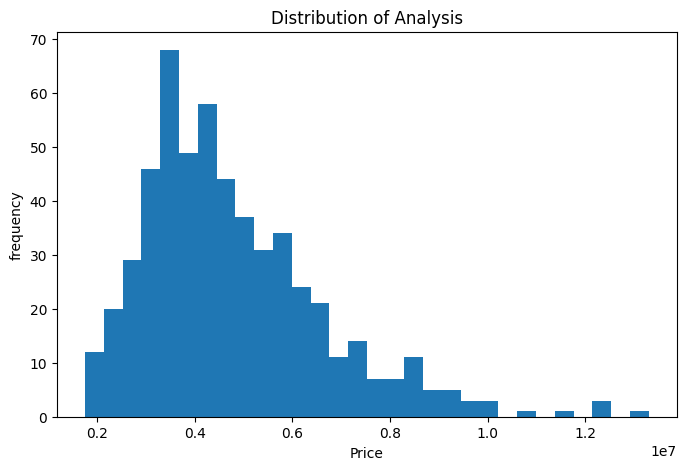

In [19]:
plt.figure(figsize=(8,5))
plt.hist(data['price'], bins=30)
plt.title("Distribution of Analysis")
plt.xlabel('Price')
plt.ylabel('frequency')
plt.show()

## 3.8 Categorical analysis

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

mainroad
['yes' 'no']
mainroad
yes    468
no      77
Name: count, dtype: int64


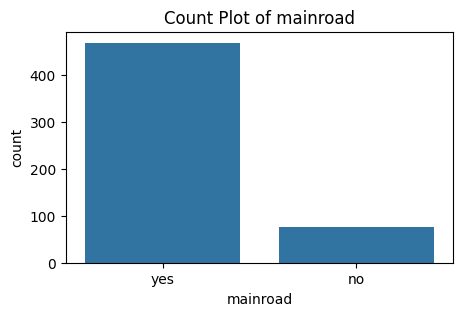


guestroom
['no' 'yes']
guestroom
no     448
yes     97
Name: count, dtype: int64


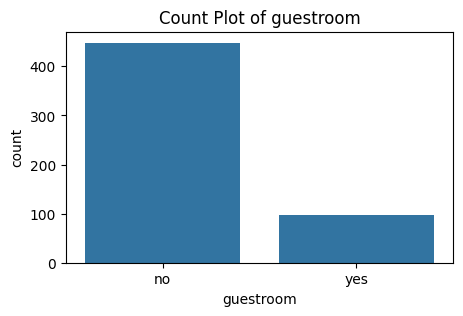


basement
['no' 'yes' nan]
basement
no     354
yes    190
Name: count, dtype: int64


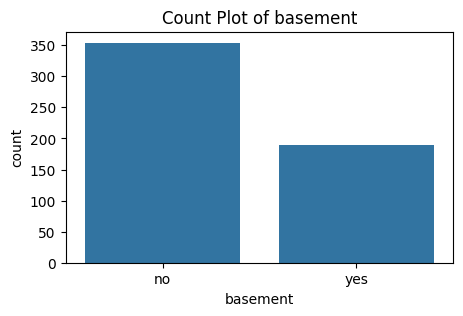


hotwaterheating
['no' 'yes']
hotwaterheating
no     520
yes     25
Name: count, dtype: int64


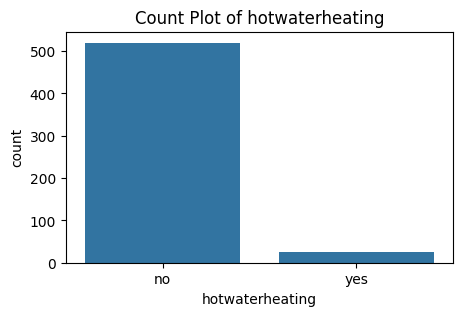


airconditioning
['yes' 'no']
airconditioning
no     373
yes    172
Name: count, dtype: int64


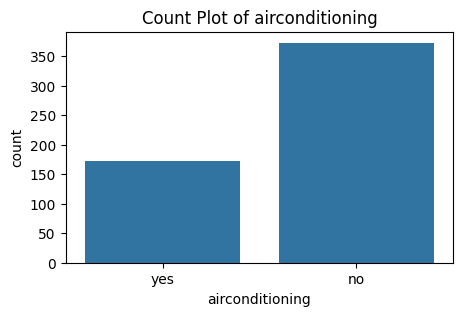


prefarea
['yes' 'no']
prefarea
no     417
yes    128
Name: count, dtype: int64


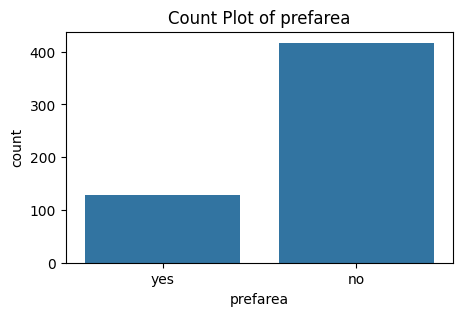


furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']
furnishingstatus
semi-furnished    227
unfurnished       179
furnished         139
Name: count, dtype: int64


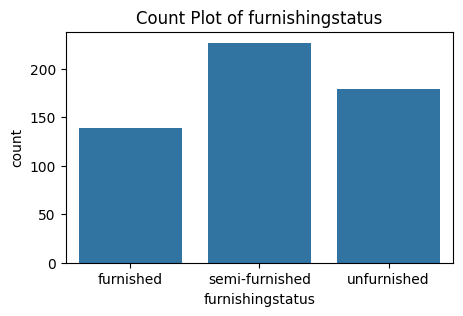

In [27]:
categorical_columns = data.select_dtypes(include=['object']).columns
print(categorical_columns)

for col in categorical_columns:
    print(f"\n{col}")
    print(data[col].unique())
    print(data[col].value_counts())
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=data)
    plt.title(f"Count Plot of {col}")
    plt.show()

## 3.9 Scatter Plot

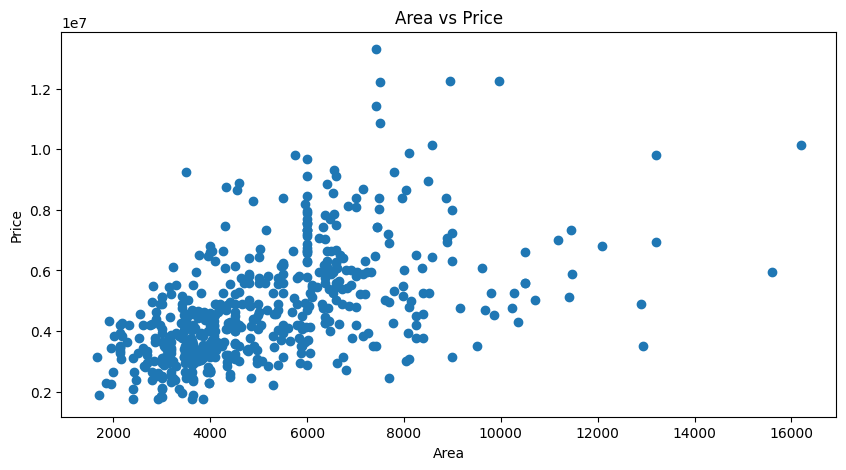

In [29]:
plt.figure(figsize=(10, 5))

plt.scatter(data['area'], data['price'])
plt.xlabel("Area")
plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

## 3.10 Outlier Detection

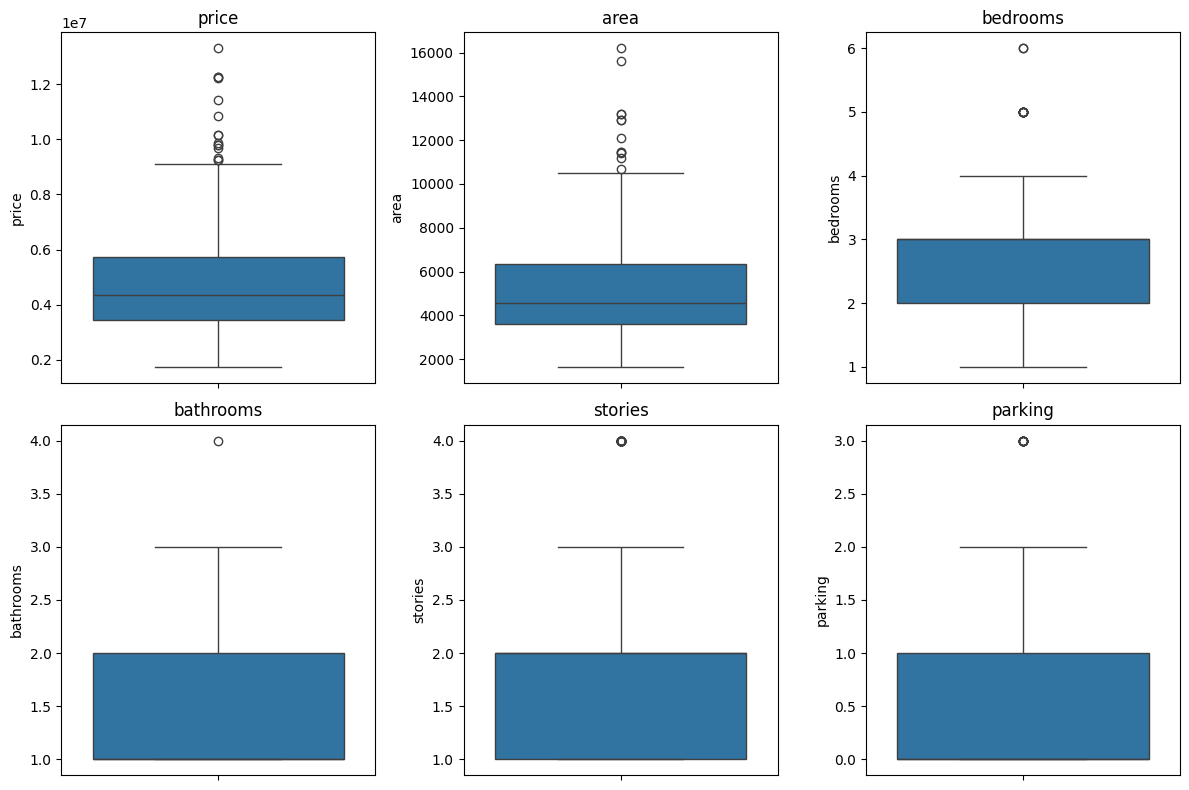

In [33]:
plt.figure(figsize=(12,8))
numerical_columns = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

## 4.1 Handle Missing Value

In [34]:
data['area'] = data['area'].fillna(data['area'].median())

In [35]:
data['basement'] = data['basement'].fillna(data['basement'].mode()[0])

## 4.2 Handle Categorical Feature

In [36]:
data.select_dtypes(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,no,no,yes,no,unfurnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [37]:
binary_cols = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

In [38]:
data = pd.get_dummies(
    data, 
    columns=['furnishingstatus'],
    drop_first = True, 
    dtype = int
)
dummy_cols = [
    "furnishingstatus_semi-furnished",
    "furnishingstatus_unfurnished"
]

data[dummy_cols] = data[dummy_cols].astype(int)

In [39]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420.0,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960.0,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960.0,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500.0,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420.0,4,1,2,1,1,0,0,1,2,0,0,1


# 5. Feature Selection

In [42]:
x = data.drop('price', axis=1)
y = data['price']
print(x.shape)
print(y.shape)

(545, 13)
(545,)


# 6. Train - Test Split

## 6.1 Suffle

In [43]:
indices = np.arange(len(x))
np.random.shuffle(indices)

x = x.iloc[indices].reset_index(drop=True)
y = y.iloc[indices].reset_index(drop=True)

## 6.2 Calculate Train size

In [46]:
train_size = int(0.8 * len(x))
print(train_size)

436


## 6.3 Split Data

In [49]:
x_train = x[:train_size]
x_test = x[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

## 6.4 Verify

In [51]:
print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436, 13)
X_test : (109, 13)
y_train: (436,)
y_test : (109,)


# 7. Feature Scaling

In [52]:
mean = x_train.mean()
std = x_train.std()